# SVD with a Dog Image: Modes, Snapshots, and Pseudo-Inverse

Today I want to use one image to show three ideas:

1. $X = U \Sigma V^T$
2. The columns of $U$ and $V$ describe dominant patterns in the data
3. The same SVD gives the pseudo-inverse for least-squares and minimum-norm solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 13

def svd_pinv(matrix, tol=1e-10):
    left, sing, right_t = np.linalg.svd(matrix, full_matrices=False)
    sing_inv = np.array([1/x if x > tol else 0 for x in sing])
    return right_t.T @ np.diag(sing_inv) @ left.T

dog = imread("dogs.jpg")

if dog.ndim == 3:
    gray = np.mean(dog[..., :3], axis=2).astype(float)
else:
    gray = dog.astype(float)

## Step 1: the image is a matrix

The grayscale image is a matrix $X$.
Each entry is one pixel intensity.

We take the SVD:

$X = U \Sigma V^T$

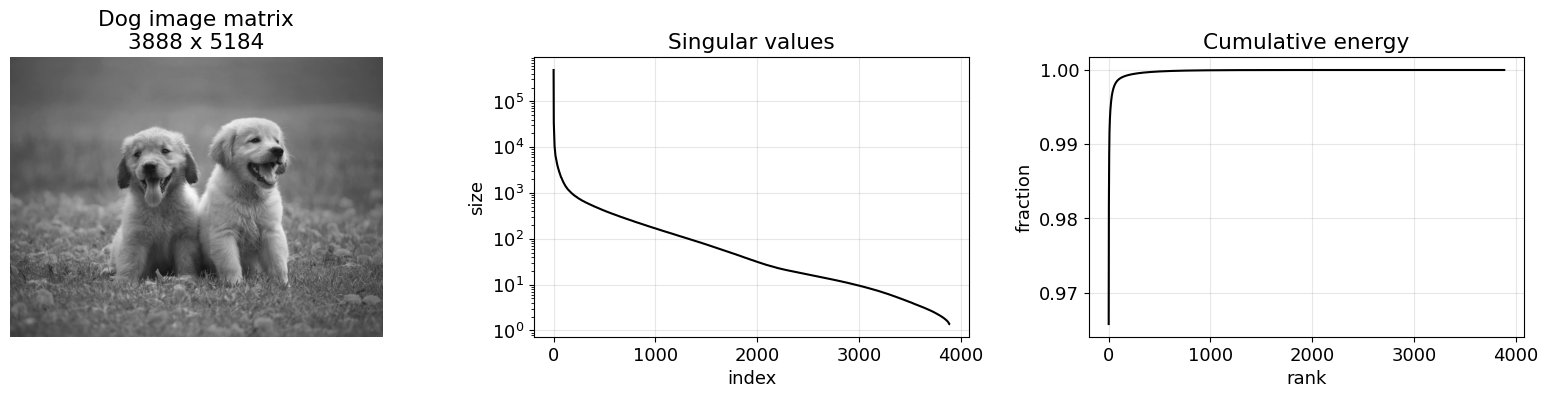

gray shape: (3888, 5184)
first 8 singular values: [482743.22  51553.66  34157.88  28675.87  21090.82  20710.17  17878.86
  14768.89]
rank for 90% energy: 1
rank for 95% energy: 1


In [2]:
left, sing, right_t = np.linalg.svd(gray, full_matrices=False)
energy = np.cumsum(sing**2) / np.sum(sing**2)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].imshow(gray, cmap="gray")
ax[0].axis("off")
ax[0].set_title(f"Dog image matrix\n{gray.shape[0]} x {gray.shape[1]}")

ax[1].semilogy(sing, color="black")
ax[1].set_title("Singular values")
ax[1].set_xlabel("index")
ax[1].set_ylabel("size")
ax[1].grid(alpha=0.3)

ax[2].plot(energy, color="black")
ax[2].set_title("Cumulative energy")
ax[2].set_xlabel("rank")
ax[2].set_ylabel("fraction")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

rank_90 = np.searchsorted(energy, 0.90) + 1
rank_95 = np.searchsorted(energy, 0.95) + 1

print(f"gray shape: {gray.shape}")
print(f"first 8 singular values: {np.round(sing[:8], 2)}")
print(f"rank for 90% energy: {rank_90}")
print(f"rank for 95% energy: {rank_95}")

## Step 2: what do the singular vectors look like?

- Columns of $U$ are row-direction patterns
- Rows of $V^T$ are column-direction patterns
- Each term $\sigma_k u_k v_k^T$ is one rank-1 image

So instead of jumping straight to compression, I want to look at the building blocks.

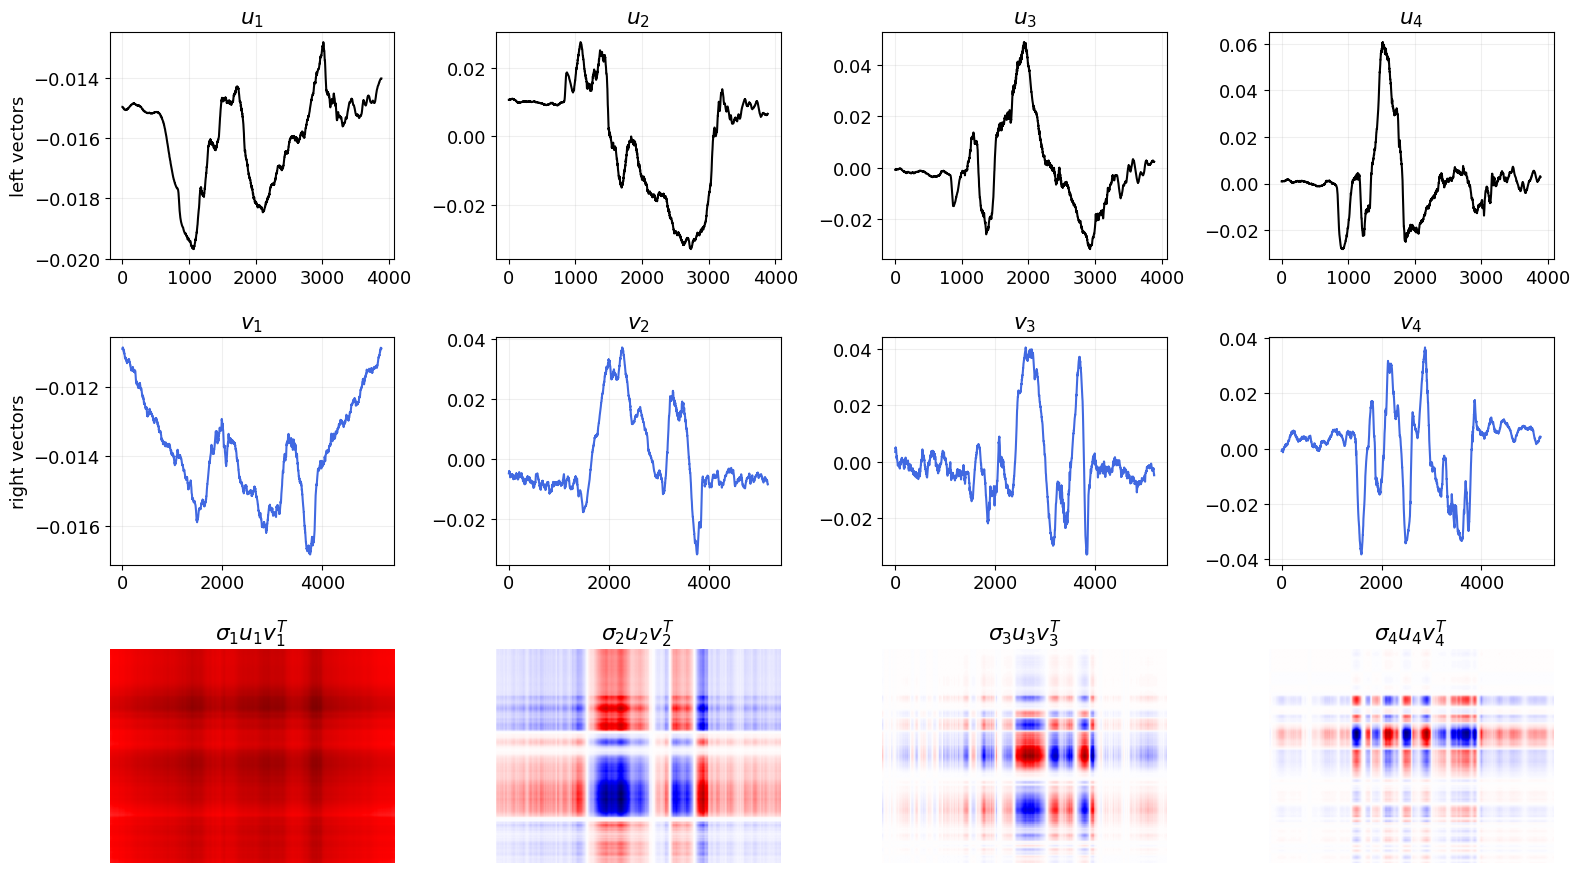

In [3]:
modes = [0, 1, 2, 3]

fig, ax = plt.subplots(3, 4, figsize=(16, 9))

for j, k in enumerate(modes):
    ax[0, j].plot(left[:, k], color="black")
    ax[0, j].set_title(f"$u_{k+1}$")
    ax[0, j].grid(alpha=0.2)

    ax[1, j].plot(right_t[k, :], color="royalblue")
    ax[1, j].set_title(f"$v_{k+1}$")
    ax[1, j].grid(alpha=0.2)

    layer = sing[k] * np.outer(left[:, k], right_t[k, :])
    lim = np.max(np.abs(layer))
    ax[2, j].imshow(layer, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2, j].axis("off")
    ax[2, j].set_title(f"$\\sigma_{k+1} u_{k+1} v_{k+1}^T$")

ax[0, 0].set_ylabel("left vectors")
ax[1, 0].set_ylabel("right vectors")
ax[2, 0].set_ylabel("rank-1 layers")

plt.tight_layout()
plt.show()

## Step 3: method of snapshots

For a large matrix, building $XX^T$ can be expensive.

So we can work with the smaller matrix $X^T X$,
find its eigenvectors,
and then recover the left singular vectors from

$U_r = X V_r \Sigma_r^{-1}$

Now I want to verify that numerically.

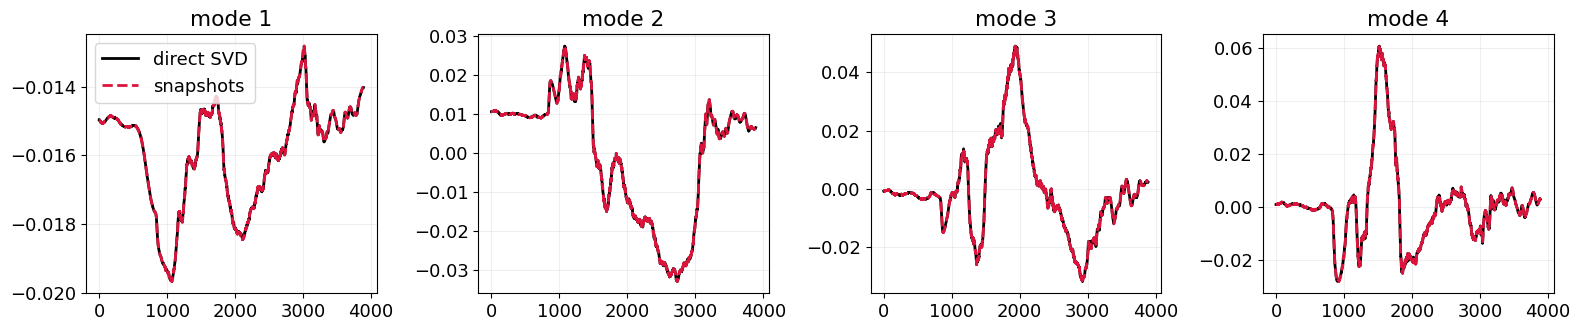

first 6 singular values from SVD:
[482743.2219  51553.6629  34157.8762  28675.8721  21090.8184  20710.1654]

first 6 singular values from X^T X:
[482743.2219  51553.6629  34157.8762  28675.8721  21090.8184  20710.1654]

max absolute mismatch in first 6: 2.444721758365631e-09


In [4]:
small_corr = gray.T @ gray

eigvals, eigvecs = np.linalg.eigh(small_corr)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

keep = eigvals > 1e-10
snap_sing = np.sqrt(eigvals[keep])
snap_right = eigvecs[:, keep]
snap_left = gray @ snap_right / snap_sing

for k in range(4):
    if np.dot(left[:, k], snap_left[:, k]) < 0:
        snap_left[:, k] *= -1
        snap_right[:, k] *= -1

fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))

for k in range(4):
    ax[k].plot(left[:, k], color="black", linewidth=2, label="direct SVD")
    ax[k].plot(snap_left[:, k], "--", color="crimson", linewidth=2, label="snapshots")
    ax[k].set_title(f"mode {k+1}")
    ax[k].grid(alpha=0.2)

ax[0].legend()
plt.tight_layout()
plt.show()

print("first 6 singular values from SVD:")
print(np.round(sing[:6], 4))
print()
print("first 6 singular values from X^T X:")
print(np.round(snap_sing[:6], 4))
print()
print("max absolute mismatch in first 6:", np.max(np.abs(sing[:6] - snap_sing[:6])))

## Step 4: pseudo-inverse for an over-determined system

If $Ax = b$ has no exact solution, the pseudo-inverse gives the least-squares fit

$\tilde{x} = A^{-1} b$

Geometrically, $A \tilde{x}$ is the projection of $b$ onto the column space of $A$.

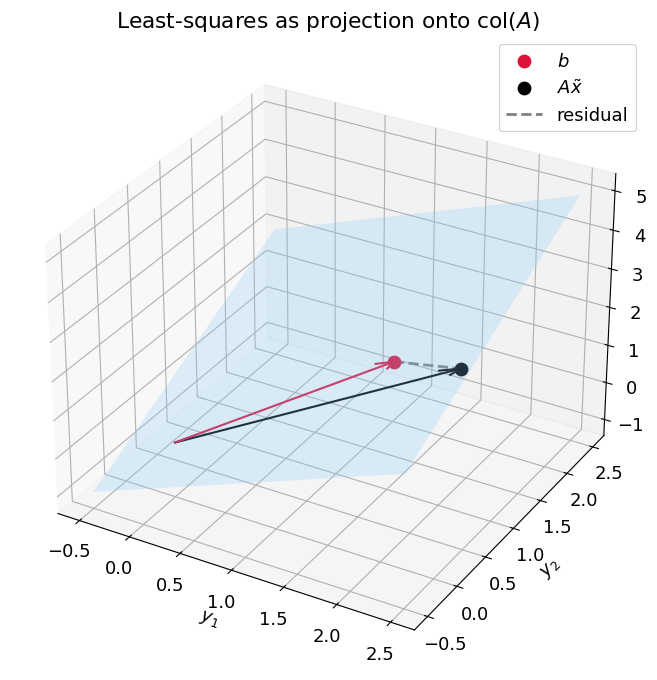

x_tilde = [2.4 0.6]
A x_tilde = [2.4 0.6 3. ]
residual norm = 0.6928


In [5]:
A_tall = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])

b = np.array([2.0, 0.2, 3.4])

x_fit = svd_pinv(A_tall) @ b
b_fit = A_tall @ x_fit
residual = b - b_fit

col1 = A_tall[:, 0]
col2 = A_tall[:, 1]

s1, s2 = np.meshgrid(np.linspace(-0.5, 2.5, 12), np.linspace(-0.5, 2.5, 12))
plane = np.outer(s1.ravel(), col1) + np.outer(s2.ravel(), col2)

Xp = plane[:, 0].reshape(s1.shape)
Yp = plane[:, 1].reshape(s1.shape)
Zp = plane[:, 2].reshape(s1.shape)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Xp, Yp, Zp, alpha=0.25, color="lightskyblue", edgecolor="none")
ax.scatter(*b, color="crimson", s=80, label="$b$")
ax.scatter(*b_fit, color="black", s=80, label="$A\\tilde{x}$")

ax.plot([b[0], b_fit[0]], [b[1], b_fit[1]], [b[2], b_fit[2]],
        "--", color="gray", linewidth=2, label="residual")

ax.quiver(0, 0, 0, b[0], b[1], b[2], color="crimson", arrow_length_ratio=0.06)
ax.quiver(0, 0, 0, b_fit[0], b_fit[1], b_fit[2], color="black", arrow_length_ratio=0.06)

ax.set_xlabel("$y_1$")
ax.set_ylabel("$y_2$")
ax.set_zlabel("$y_3$")
ax.set_title("Least-squares as projection onto col$(A)$")
ax.legend()

plt.tight_layout()
plt.show()

print("x_tilde =", np.round(x_fit, 4))
print("A x_tilde =", np.round(b_fit, 4))
print("residual norm =", np.linalg.norm(residual).round(4))

## Step 5: pseudo-inverse for an under-determined system

If there are infinitely many exact solutions, the pseudo-inverse picks the minimum-norm one.

I will show that with a one-equation, two-unknown system.

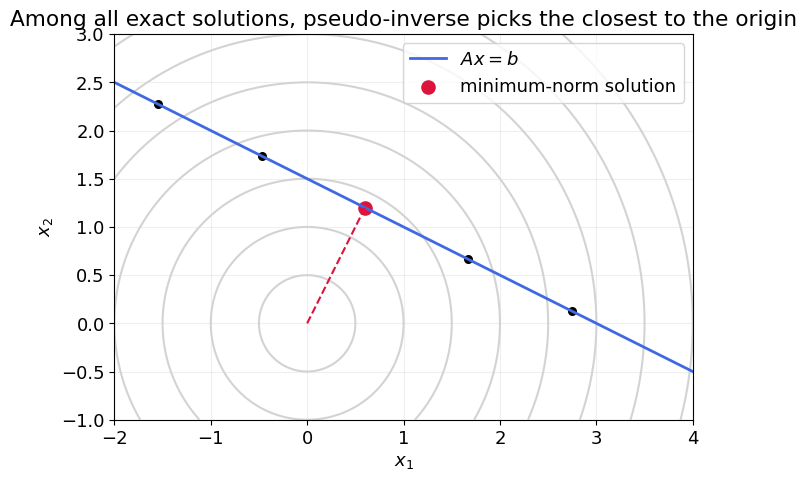

x_star = [0.6 1.2]
A x_star = [3.]
norm of x_star = 1.3416


In [6]:
A_wide = np.array([[1.0, 2.0]])
b_wide = np.array([3.0])

x_star = (svd_pinv(A_wide) @ b_wide).ravel()

x1 = np.linspace(-2, 4, 400)
x2 = (b_wide[0] - x1) / 2

grid_x, grid_y = np.meshgrid(np.linspace(-2, 4, 250), np.linspace(-1, 3, 250))
radius = np.sqrt(grid_x**2 + grid_y**2)

fig, ax = plt.subplots(figsize=(7, 6))

ax.contour(grid_x, grid_y, radius, levels=np.arange(0.5, 4.5, 0.5), colors="lightgray")
ax.plot(x1, x2, color="royalblue", linewidth=2, label="$Ax=b$")

null_dir = np.array([2.0, -1.0])
null_dir = null_dir / np.linalg.norm(null_dir)

for t in [-2, -1, 1, 2]:
    other = x_star + 1.2 * t * null_dir
    ax.scatter(other[0], other[1], color="black", s=30)

ax.scatter(x_star[0], x_star[1], color="crimson", s=90, label="minimum-norm solution")
ax.plot([0, x_star[0]], [0, x_star[1]], "--", color="crimson")

ax.set_xlim(-2, 4)
ax.set_ylim(-1, 3)
ax.set_aspect("equal")
ax.grid(alpha=0.2)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Among all exact solutions, pseudo-inverse picks the closest to the origin")
ax.legend()

plt.tight_layout()
plt.show()

print("x_star =", np.round(x_star, 4))
print("A x_star =", np.round(A_wide @ x_star, 4))
print("norm of x_star =", np.linalg.norm(x_star).round(4))

## Takeaways

- The dog image is just a matrix
- SVD breaks that matrix into orthogonal patterns
- The method of snapshots recovers the same leading modes from $X^T X$
- The pseudo-inverse gives least-squares for tall systems
- The pseudo-inverse gives minimum-norm solutions for wide systems